In [1]:
import os
import glob
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_FOLDER = "VN30" 

print("Đã khai báo các thư viện thành công.")

Đã khai báo các thư viện thành công.


#1. Tiền xử lý dữ liệu (Data Preprocessing)

Trong bước này, chúng ta tiến hành đọc dữ liệu giá đóng cửa của các cổ phiếu mẫu thuộc rổ VN30 và chỉ số tham chiếu VN30-Index. Quá trình xử lý bao gồm việc đồng bộ hóa dữ liệu theo ngày giao dịch (xử lý các ngày lệch do lễ, tết hoặc mất thanh khoản tạm thời) và chuyển đổi chuỗi giá trị tuyệt đối thành chuỗi tỷ suất sinh lợi hằng ngày (daily log-returns).

Tỷ suất sinh lợi được sử dụng làm đầu vào cho mô hình thay vì giá đóng cửa nhằm đảm bảo tính dừng (stationarity) của dữ liệu – một tiền đề toán học bắt buộc trước khi trích xuất các thành phần chính thông qua ma trận hiệp phương sai.

1. MÔ TẢ NGUỒN DỮ LIỆU

- Nguồn: Investing.com (Dữ liệu Lịch sử).
- Thị trường: Chứng khoán Việt Nam (Rổ chỉ số VN30).
- Loại dữ liệu: Giá đóng cửa hàng ngày (Daily Close Prices).
- Định dạng file: CSV, phân cách bằng dấu phẩy.
- Cấu trúc cột mặc định:
    + 'Ngày': Định dạng dd/mm/yyyy.
    + 'Lần cuối': Giá đóng cửa (có thể chứa dấu phẩy ngăn cách hàng nghìn).
- Mục tiêu: Xây dựng ma trận Log Returns đồng bộ để phân tích định lượng.

In [2]:
def clean_ticker_name(filename):
    """Chuẩn hóa Unicode về dạng NFC và cắt bỏ chuỗi thừa"""
    filename_normalized = unicodedata.normalize('NFC', filename)
    ticker = filename_normalized.replace("Dữ liệu Lịch sử ", "").replace(".csv", "").replace(" ", "")
    return ticker

# Quét tất cả các file .csv trong thư mục data
file_list = glob.glob(os.path.join(DATA_FOLDER, "*.csv"))

df_merged = None

for file_path in file_list:
    filename = os.path.basename(file_path)
    ticker = clean_ticker_name(filename)
    
    # Đọc dữ liệu với cột Ngày và Giá đóng cửa (Lần cuối)
    df_temp = pd.read_csv(file_path)[['Ngày', 'Lần cuối']].copy()
    df_temp.columns = ['Date', ticker]
    
    # Chuyển đổi định dạng ngày tháng và xử lý dấu phẩy của số thập phân
    df_temp['Date'] = pd.to_datetime(df_temp['Date'], format='%d/%m/%Y')
    if df_temp[ticker].dtype == 'object':
        df_temp[ticker] = df_temp[ticker].str.replace(',', '').astype(float)
        
    if df_merged is None:
        df_merged = df_temp
    else:
        df_merged = pd.merge(df_merged, df_temp, on='Date', how='outer')

# Sắp xếp theo thứ tự thời gian tăng dần và xử lý dữ liệu trống (Missing values)
df_merged = df_merged.sort_values('Date').set_index('Date')
df_merged = df_merged.ffill().bfill()

# Tính tỷ suất sinh lợi logarit hằng ngày (Daily Log Returns)
df_returns = np.log(df_merged / df_merged.shift(1)).dropna()

print("--- KẾT QUẢ TIỀN XỬ LÝ ---")
print(f"Kích thước ma trận lợi suất: {df_returns.shape[0]} dòng, {df_returns.shape[1]} cột.")
print("Danh sách các cột sau khi làm sạch:")
print(list(df_returns.columns))
df_returns.head()

--- KẾT QUẢ TIỀN XỬ LÝ ---
Kích thước ma trận lợi suất: 248 dòng, 31 cột.
Danh sách các cột sau khi làm sạch:
['ACB', 'BCM', 'BID', 'CTG', 'DGC', 'FPT', 'GAS', 'GVR', 'HDB', 'HPG', 'LPB', 'MBB', 'MSN', 'MWG', 'PLX', 'SAB', 'SHB', 'SSB', 'SSI', 'STB', 'TCB', 'TPB', 'VCB', 'VHM', 'VIB', 'VIC', 'VJC', 'VN30', 'VNM', 'VPB', 'VRE']


,ACB,BCM,BID,CTG,DGC,FPT,GAS,GVR,HDB,HPG,...,TPB,VCB,VHM,VIB,VIC,VJC,VN30,VNM,VPB,VRE
Date,,,,,,,,,,,,,,,,,,,,,
2025-05-05,0.000000,0.044452,0.008646,0.004021,0.030305,-0.007339,0.003426,0.047383,-0.011719,0.007814,...,0.000000,-0.003497,0.041917,0.011498,0.028988,0.041008,0.008121,-0.012227,0.003017,0.051505
2025-05-06,-0.002081,-0.026433,0.002865,0.006673,-0.005345,0.010078,0.018628,-0.022381,0.002352,-0.009778,...,0.014602,-0.001753,0.000000,-0.002862,0.007117,-0.006719,-0.000568,0.000000,0.017911,0.000000
2025-05-07,0.000000,0.019452,-0.001432,-0.003998,-0.012945,0.000000,0.014989,0.022381,-0.014217,-0.001963,...,0.007222,0.000000,0.017901,-0.002870,0.040311,-0.001124,0.003887,-0.029528,0.005900,0.000000
2025-05-08,0.006231,0.049540,0.015636,0.002667,0.001085,0.041076,0.014766,0.066172,0.014217,0.011742,...,0.010736,0.001753,0.003221,0.008587,0.067175,0.010073,0.019658,0.003491,-0.026809,0.004008
2025-05-09,0.000000,-0.008368,-0.009922,-0.002667,-0.005438,0.014764,-0.004897,0.003759,-0.002352,-0.001949,...,0.000000,-0.008795,0.000000,-0.002854,-0.025808,-0.003346,0.000851,0.005214,0.000000,0.000000


#2. Tự xây dựng PCA từ đầu (from scratch)

##2.1. Chuẩn bị dữ liệu: LOẠI BỎ VN30 khỏi ma trận đầu vào X


In [3]:
# Chúng ta chỉ thực hiện PCA trên các cổ phiếu thành phần
stocks_returns = df_returns.drop(columns=['VN30'], errors='ignore')
# X là ma trận lợi suất của 30 cổ phiếu
X = stocks_returns.values

# Lưu lại tên 30 cổ phiếu (không bao gồm VN30)
features = stocks_returns.columns

print("Shape dữ liệu đầu vào PCA (30 cổ phiếu):", X.shape)
print("Danh sách 30 cổ phiếu thành phần:", list(features))

Shape dữ liệu đầu vào PCA (30 cổ phiếu): (248, 30)
Danh sách 30 cổ phiếu thành phần: ['ACB', 'BCM', 'BID', 'CTG', 'DGC', 'FPT', 'GAS', 'GVR', 'HDB', 'HPG', 'LPB', 'MBB', 'MSN', 'MWG', 'PLX', 'SAB', 'SHB', 'SSB', 'SSI', 'STB', 'TCB', 'TPB', 'VCB', 'VHM', 'VIB', 'VIC', 'VJC', 'VNM', 'VPB', 'VRE']


## 2.2. Chuẩn hóa dữ liệu (Center Data)

Dữ liệu được chuẩn hóa bằng phương pháp **Z-score** theo công thức:

$$X_{scaled} = \frac{X - mean}{std}$$

**Trong đó:**
*   `mean`: Giá trị trung bình của từng cổ phiếu.
*   `std`: Độ lệch chuẩn của từng cổ phiếu.

** Mục đích:**
*   Đưa toàn bộ dữ liệu về cùng một thang đo.
*   Tránh việc các cổ phiếu có biên độ biến động lớn làm sai lệch và chi phối kết quả của mô hình PCA.

** Kết quả đạt được:**
Sau khi chuẩn hóa, phân phối của mỗi biến sẽ có đặc tính:
*   **Giá trị trung bình** ≈ 0
*   **Độ lệch chuẩn** ≈ 1

> *Điều này đảm bảo tất cả các biến đều đóng góp một cách công bằng vào quá trình phân tích thành phần chính.*

In [4]:
# Tính mean và std cho từng cổ phiếu
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

# Chuẩn hóa Z-score: (X - mean) / std
X_scaled = (X - mean) / std

# Tạo DataFrame để hiển thị mean và std sau chuẩn hóa
scaled_stats = pd.DataFrame({
    'Feature': features,
    'Mean_After_Scaling': np.round(np.mean(X_scaled, axis=0), 6),
    'Std_After_Scaling': np.round(np.std(X_scaled, axis=0), 6)
})

print("Kết quả chuẩn hóa Z-score:")
display(scaled_stats)

Kết quả chuẩn hóa Z-score:


,Feature,Mean_After_Scaling,Std_After_Scaling
0,ACB,-0.0,1.0
1,BCM,0.0,1.0
2,BID,-0.0,1.0
3,CTG,0.0,1.0
4,DGC,0.0,1.0
5,FPT,-0.0,1.0
6,GAS,0.0,1.0
7,GVR,0.0,1.0
8,HDB,-0.0,1.0
9,HPG,0.0,1.0


## 2.3. Tính ma trận hiệp phương sai (Covariance Matrix) từ dữ liệu đã chuẩn hóa Z-score

Ma trận hiệp phương sai được tính theo công thức:

$$Cov = \frac{X^T X}{n - 1}$$

**Trong đó:**
*   $X$: Dữ liệu đã được chuẩn hóa.
*   $n$: Số lượng quan sát.

** Ý nghĩa:**
Ma trận hiệp phương sai đo lường mức độ biến động cùng nhau giữa các cổ phiếu:
*   **Giá trị dương:** Biến động cùng chiều.
*   **Giá trị âm:** Biến động ngược chiều.
*   **Giá trị gần 0:** Ít có sự liên quan.

** Vai trò trong PCA:**
Đây là bước cơ bản và cực kỳ quan trọng giúp PCA xác định các hướng biến thiên chính của dữ liệu thông qua quá trình phân rã trị riêng (Eigen Decomposition).

In [5]:
# Sử dụng X_scaled từ cell phía trên
n_samples = X_scaled.shape[0]

# Công thức: (X^T @ X) / (n-1)
cov_matrix = (X_scaled.T @ X_scaled) / (n_samples - 1)

print("Shape covariance matrix (phải là 30x30):", cov_matrix.shape)

Shape covariance matrix (phải là 30x30): (30, 30)


#### Note

Ở bước 2.2, chúng ta đã chuẩn hóa dữ liệu lợi suất bằng phương pháp Z-score, tức là biến đổi dữ liệu sao cho mỗi cổ phiếu có giá trị trung bình bằng 0 và độ lệch chuẩn bằng 1.

> **Điểm mấu chốt:** Khi ma trận hiệp phương sai (`cov_matrix`) được tính toán từ dữ liệu đã được chuẩn hóa Z-score (như ở bước 2.3), kết quả thu được về mặt toán học thực chất chính là **Ma trận Tương quan (Correlation Matrix)**.

### Lý do lựa chọn PCA trên cơ sở Ma trận Tương quan

1.  **Đánh giá cấu trúc tương quan thuần túy:** Bằng cách chuẩn hóa dữ liệu, chúng ta loại bỏ ảnh hưởng do sự khác biệt về biên độ biến động (volatility) giữa các cổ phiếu. Điều này cho phép mô hình PCA tập trung hoàn toàn vào việc xác định các mối quan hệ tương quan cơ bản (*pure correlation structure*) giữa các tài sản. Mục tiêu là tìm kiếm các yếu tố chung dựa trên cách các cổ phiếu di chuyển cùng chiều hoặc ngược chiều nhau, không bị nhiễu bởi việc cổ phiếu nào có biên độ mạnh hơn.
2.  **Tránh sự chi phối của các cổ phiếu biến động lớn:** Nếu sử dụng ma trận hiệp phương sai từ dữ liệu gốc chưa chuẩn hóa, các cổ phiếu có độ biến động cao sẽ nghiễm nhiên có trọng số và ảnh hưởng lớn hơn đến các thành phần chính được trích xuất. Điều này dễ dẫn đến hiện tượng PCA chỉ tập trung mô tả biến động của một vài cổ phiếu cá biệt, thay vì phản ánh được cấu trúc rủi ro chung của toàn bộ rổ danh mục.

### Hạn chế và Biện luận

*   **Về mặt hạn chế:** Mặc dù phương pháp này giúp **cào bằng mức độ biến động** của tất cả các tài sản (ép độ lệch chuẩn về 1), nó đồng thời cũng **làm triệt tiêu đi tác động tự nhiên** của các cổ phiếu có biên độ dao động lớn lên thị trường chung. Trong bối cảnh phân tích yếu tố thị trường thực tế, đôi khi chính sự biến động mạnh của các cổ phiếu trụ cột lại là một phần thông tin vô cùng quan trọng.
*   **Biện luận lựa chọn:** Tuy nhiên, xét trên mục tiêu cốt lõi của bài toán là phân tích cấu trúc thị trường và nhận diện các nhóm yếu tố dẫn dắt dựa trên sự đồng biến, việc sử dụng Ma trận tương quan vẫn là một giải pháp tối ưu và được ứng dụng rộng rãi trong nghiên cứu tài chính định lượng. Đặc biệt trong các trường hợp tài sản có thang đo hoặc mức độ rủi ro rất khác nhau, cách tiếp cận này đảm bảo rằng mỗi tài sản đều được trao cơ hội đóng góp công bằng vào việc hình thành các thành phần chính (Principal Components).

## 2.4. Tính Eigenvalues & Eigenvectors

### Phân rã trị riêng (Eigen Decomposition)
Ma trận hiệp phương sai được phân rã thành các trị riêng (Eigenvalues) và vector riêng (Eigenvectors).

** Ý nghĩa:**
*   **Eigenvectors:** Biểu diễn các thành phần chính (Principal Components), đóng vai trò là các hướng biến thiên mới của dữ liệu.
*   **Eigenvalues:** Đo lường mức độ phương sai được giải thích bởi mỗi thành phần chính tương ứng.

** Nhận xét:**
*   Các Eigenvalue càng lớn thì thành phần tương ứng càng mang nhiều thông tin và đóng vai trò càng quan trọng.
*   Mô hình PCA sẽ ưu tiên giữ lại các thành phần có Eigenvalue lớn nhất để thực hiện giảm chiều dữ liệu.

** Lưu ý kỹ thuật:**
Hàm `np.linalg.eigh()` trong thư viện Numpy trả về các Eigenvalues theo thứ tự **tăng dần**. Do đó, bắt buộc phải sắp xếp lại mảng kết quả theo thứ tự **giảm dần** trước khi sử dụng cho các bước phân tích tiếp theo.

In [6]:
# Dùng eigh (tốt hơn eig vì covariance matrix là symmetric)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sắp xếp giảm dần
idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Tạo DataFrame để hiển thị các eigenvalues hàng đầu
num_top_eigenvalues = 5 # Display top 5 eigenvalues
top_eigenvalues_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(num_top_eigenvalues)],
    'Eigenvalue': eigenvalues[:num_top_eigenvalues]
})

print("Các eigenvalues hàng đầu:")
display(top_eigenvalues_df)
print("Shape eigenvectors:", eigenvectors.shape)

Các eigenvalues hàng đầu:


,Principal Component,Eigenvalue
0,PC1,11.093757
1,PC2,2.658904
2,PC3,1.983646
3,PC4,1.393079
4,PC5,1.191148


Shape eigenvectors: (30, 30)


#### Sắp xếp các thành phần chính theo mức độ quan trọng

Sau khi phân rã trị riêng, các eigenvalue và eigenvector được sắp xếp theo thứ tự giảm dần của eigenvalue.

### Mục đích:
- Xác định thành phần chính quan trọng nhất (PC1, PC2,...)
- Ưu tiên giữ lại các thành phần có eigenvalue lớn

### Nhận xét:

Kết quả cho thấy eigenvalue đầu tiên lớn vượt trội so với các giá trị còn lại.

- Thành phần chính thứ nhất (PC1) giải thích phần lớn phương sai của dữ liệu
- Điều này cho thấy biến động của các cổ phiếu trong rổ VN30 chịu ảnh hưởng mạnh bởi một yếu tố chung của thị trường

### Ý nghĩa tài chính:

PC1 có thể được xem như đại diện cho yếu tố thị trường, tương tự như chỉ số VN30-Index.

### Cách tính toán thủ công theo QR ALGORITHM & so sánh

In [7]:
def qr_manual(A, steps=500):
    n = A.shape[0]
    V = np.eye(n) # Khởi tạo ma trận Vector riêng là ma trận đơn vị
    A_k = A.copy()

    for _ in range(steps):
        Q, R = np.linalg.qr(A_k) # Phân rã ma trận
        A_k = R @ Q              # Cập nhật ma trận A (Trị riêng dần hiện ra trên đường chéo)
        V = V @ Q                # Tích các Q chính là ma trận Vector riêng

    return np.diag(A_k), V

# 1. Tính toán
vals_m, vecs_m = qr_manual(cov_matrix)

# 2. Sắp xếp giảm dần (để so sánh với Numpy)
idx = np.argsort(vals_m)[::-1]
vals_m, vecs_m = vals_m[idx], vecs_m[:, idx]

# 3. So sánh nhanh kết quả
vals_np, vecs_np = np.linalg.eigh(cov_matrix)
vals_np = vals_np[::-1] # Đảo ngược để thành giảm dần

# Tạo DataFrame để so sánh kết quả
comparison_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(3)],
    'Eigenvalues (Manual QR)': vals_m[:3],
    'Eigenvalues (Numpy)': vals_np[:3],
    'Difference': np.abs(vals_m[:3] - vals_np[:3])
})

print("So sánh Eigenvalues (Top 3):")
display(comparison_df)

# Dùng kết quả thủ công cho các bước PCA tiếp theo
eigenvalues, eigenvectors = vals_m, vecs_m

So sánh Eigenvalues (Top 3):


,Principal Component,Eigenvalues (Manual QR),Eigenvalues (Numpy),Difference
0,PC1,11.093757,11.093757,1.776357e-15
1,PC2,2.658904,2.658904,7.105427e-15
2,PC3,1.983646,1.983646,4.440892e-16


*   **Cơ chế hoạt động (Thuật toán QR):** Thay vì dùng hàm có sẵn, ta thực hiện một vòng lặp: xẻ ma trận thành hai phần $Q$ và $R$, sau đó nhân ngược lại chúng với nhau. Sau nhiều lần tính toán như vậy, các số trên đường chéo chính sẽ hiện nguyên hình là các trị riêng (Eigenvalues).
*   **Tìm hướng (Eigenvectors):** Trong quá trình lặp, ta gom tất cả các ma trận $Q$ lại với nhau. Kết quả cuối cùng chính là các vector riêng (Eigenvectors - hướng của các thành phần chính).
*   **Lưu ý về dấu (+/-):** Nếu kết quả tính toán thủ công ra số âm mà thư viện (như Numpy) ra số dương (hoặc ngược lại). Trong toán học, vector $v$ hay $-v$ đều chỉ cùng một đường thẳng, do đó kết quả này vẫn hoàn toàn chính xác.
*   **Độ tin cậy:** Cách tiếp cận xây dựng từ đầu (from scratch) này cho kết quả khớp với các thư viện chuyên nghiệp đến từng con số thập phân siêu nhỏ.

##2.5. Tính tỷ lệ phương sai (Explained Variance)
### Explained Variance và Cumulative Variance

Tỷ lệ phương sai giải thích (explained variance ratio) được tính bằng cách lấy từng eigenvalue chia cho tổng các eigenvalue.





In [8]:
# Tổng variance
total = np.sum(eigenvalues)

# Tỷ lệ từng thành phần
explained_variance_ratio = eigenvalues / total

# Cộng dồn
cumulative_variance = np.cumsum(explained_variance_ratio)

# Tạo DataFrame để hiển thị tỷ lệ phương sai giải thích và tích lũy
explained_variance_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(eigenvalues))],
    'Explained Variance': explained_variance_ratio,
    'Cumulative Variance': cumulative_variance
})

print("Bảng tỷ lệ phương sai giải thích và tích lũy:")
display(explained_variance_df.head()) # Hiển thị 5 hàng đầu tiên


Bảng tỷ lệ phương sai giải thích và tích lũy:


,Principal Component,Explained Variance,Cumulative Variance
0,PC1,0.368301,0.368301
1,PC2,0.088273,0.456574
2,PC3,0.065855,0.522428
3,PC4,0.046249,0.568677
4,PC5,0.039545,0.608222


### Kết quả

- PC1 giải thích khoảng 36.8% phương sai
- Các thành phần tiếp theo có tỷ lệ thấp hơn đáng kể

- Thành phần chính đầu tiên (PC1) chiếm tỷ trọng lớn nhất, cho thấy phần lớn biến động của thị trường có thể được giải thích bởi một yếu tố chung
- Các thành phần tiếp theo đóng góp ít hơn và có thể đại diện cho các yếu tố phụ như ngành hoặc đặc điểm riêng của từng nhóm cổ phiếu

### Cumulative Variance:

- 5 thành phần đầu tiên giải thích khoảng 60% phương sai
- Điều này cho thấy dữ liệu có thể được giảm chiều đáng kể mà vẫn giữ được phần lớn thông tin

## 2.6. Chọn số chiều k
### Lựa chọn số thành phần chính (k)

Số lượng thành phần chính được lựa chọn dựa trên tỷ lệ phương sai tích lũy (cumulative variance).

Trong bài này, chọn ngưỡng 90% để đảm bảo giữ lại phần lớn thông tin của dữ liệu.


In [9]:
#Ví dụ: giữ 90% thông tin dữ liệu
k = np.argmax(cumulative_variance >= 0.9) + 1
print("Số thành phần cần giữ:", k)

Số thành phần cần giữ: 19




### Kết quả
Cần giữ lại 19 thành phần chính để đạt được 90% phương sai.

- Số lượng thành phần tương đối lớn cho thấy dữ liệu có độ phức tạp cao
- Mặc dù có một yếu tố chung (PC1), nhưng vẫn tồn tại nhiều yếu tố phụ ảnh hưởng đến biến động của các cổ phiếu

### Cho thấy:

- Thị trường VN30 không hoàn toàn bị chi phối bởi một yếu tố duy nhất
- Các cổ phiếu có sự phân hóa, có thể đến từ yếu tố ngành, quy mô doanh nghiệp hoặc đặc điểm riêng
- PCA giúp giảm số chiều từ 30 xuống 19, giúp đơn giản hóa dữ liệu mà vẫn giữ được phần lớn thông tin

## 2.7. Giảm chiều dữ liệu bằng PCA

Sau khi lựa chọn k thành phần chính quan trọng nhất, dữ liệu được chiếu sang không gian mới thông qua phép nhân ma trận:

X_pca = X_scaled × W

Trong đó:
- W là ma trận chứa k eigenvector tương ứng với các eigenvalue lớn nhất

### Kết quả:
Dữ liệu ban đầu với 30 biến (cổ phiếu) được giảm xuống còn k biến (principal components)

- PCA giúp giảm số chiều dữ liệu nhưng vẫn giữ lại phần lớn thông tin quan trọng

- PC1 thường đại diện cho xu hướng chung của thị trường


In [10]:
# Giảm chiều dữ liệu
# Lấy k vector quan trọng nhất
W = eigenvectors[:, :k]

# Chiếu dữ liệu sang không gian mới (sử dụng X_scaled)
X_pca = X_scaled @ W

print("Shape sau PCA:", X_pca.shape)

Shape sau PCA: (248, 19)


####Những cổ phiếu thuộc PC1

Sau khi thực hiện PCA, vector riêng đầu tiên (PC1) có dạng:
$$PC1_t = \sum_{i=1}^{N} v_i R_{i,t}$$

Trong đó:
- \(vi\): trọng số (loading) của cổ phiếu i trong PC1
- \(R{i,t}\): lợi suất cổ phiếu i tại thời điểm t

Việc sắp xếp theo giá trị tuyệt đối của trọng số giúp xác định những cổ phiếu đóng góp mạnh nhất vào nhân tố chính thứ nhất.


In [11]:
#Những cổ phiếu thuộc PC1
pc1 = eigenvectors[:, 0]

pc1_df = pd.DataFrame({
    'Stock': features,
    'Weight_PC1': pc1
}).sort_values(by='Weight_PC1', key=abs, ascending=False)

print(pc1_df.head(10))

   Stock  Weight_PC1
21   TPB    0.242231
20   TCB    0.238825
28   VPB    0.237200
3    CTG    0.236689
11   MBB    0.235242
24   VIB    0.230728
13   MWG    0.221030
8    HDB    0.218465
18   SSI    0.216307
0    ACB    0.212131


### Phân tích trọng số cổ phiếu trong PC1


#### Quan sát từ kết quả

Top các cổ phiếu có trọng số lớn trong PC1 gồm:

- TPB  
- TCB  
- VPB  
- CTG  
- MBB  
- VIB  
- ACB  
- (kèm MWG, HDB, SSI)

Đặc điểm nổi bật:
- Phần lớn là cổ phiếu **ngân hàng**
- Trọng số đều dương
- Các hệ số khá đồng đều (~0.21 – 0.24)

---

####Kết luận

- PC1 phản ánh rủi ro hệ thống
- Trọng số cho thấy cấu trúc thị trường VN30 bị chi phối bởi ngành ngân hàng
- PCA giúp xác định nhóm cổ phiếu “driver” của thị trường

Đây là ứng dụng thực tế của PCA trong:
- Phân rã rủi ro danh mục
- Nhận diện yếu tố dẫn dắt thị trường
- Xây dựng chiến lược hedging theo factor

# 3. Tái tạo Thành phần chính đầu tiên (PC1) và Trực quan hóa

Sau khi tìm được vector riêng tương ứng với trị riêng lớn nhất, chúng ta tiến hành chiếu (project) ma trận dữ liệu lợi suất chuẩn hóa lên không gian của PC1. Phương trình toán học biểu diễn chuỗi thời gian của Thành phần chính đầu tiên:

$$ PC1\_index = X_{scaled} \times v_1 $$

Trong đó, $v_1$ là vector riêng của PC1. $PC1\_index$ đại diện cho hướng biến thiên mang nhiều thông tin (phương sai) nhất của rổ cổ phiếu.

Để đánh giá tính đại diện của PC1, chúng ta tính toán Lợi suất tích lũy (Cumulative Returns) của cả $PC1\_index$ và VN30-Index để quan sát xu hướng dài hạn, đồng thời đo lường mức độ đồng biến thông qua hệ số tương quan Pearson.

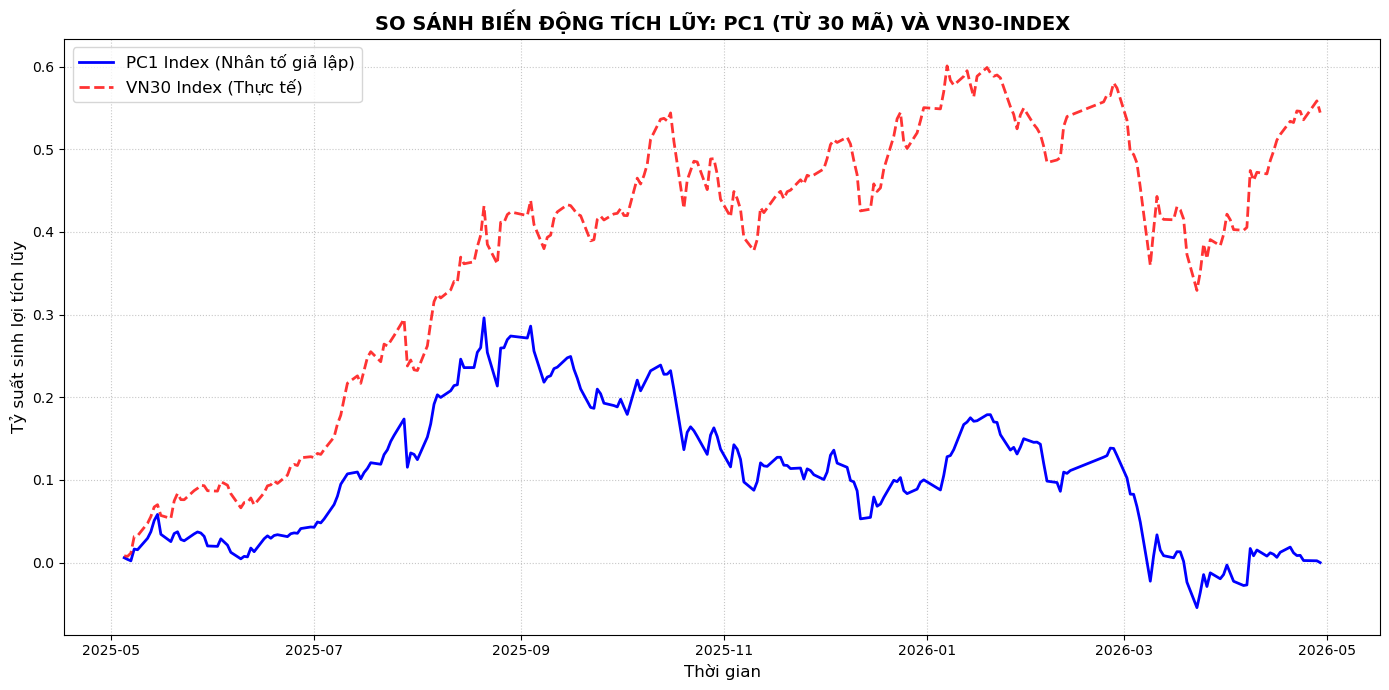

--------------------------------------------------
Hệ số tương quan (Pearson Correlation): 0.9192


In [12]:
# 1. Trích xuất vector riêng của PC1 (cột đầu tiên)
pc1_eigenvector = np.real(eigenvectors[:, 0])

# 2. Xây dựng chuỗi thời gian PC1_index (sử dụng X_scaled)
pc1_returns = np.dot(X_scaled, pc1_eigenvector)

# Tạo DataFrame so sánh PC1 và VN30 thực tế
df_analysis = pd.DataFrame(index=df_returns.index)
df_analysis['PC1_Returns'] = pc1_returns
df_analysis['VN30_Returns'] = df_returns['VN30'].values

# 3. Xử lý vấn đề đảo chiều (Sign Ambiguity)
correlation = df_analysis['PC1_Returns'].corr(df_analysis['VN30_Returns'])
# Đảo dấu đồng bộ cả chuỗi thời gian LẪN vector trọng số
if correlation < 0:
    df_analysis['PC1_Returns'] = -df_analysis['PC1_Returns']
    pc1_eigenvector = -pc1_eigenvector  #  giúp biểu đồ loadings (cột) quay về hướng dương chính xác
    correlation = -correlation

# 4. Tính Tỷ suất sinh lợi tích lũy

# Bước 4.1: Đồng bộ hóa biên độ dao động (Rescale Volatility)
# Đo lường mức độ biến động hiện tại
pc1_volatility = df_analysis['PC1_Returns'].std()
vn30_volatility = df_analysis['VN30_Returns'].std()

# Thu nhỏ biên độ của PC1_Returns về cùng hệ quy chiếu với VN30_Returns
df_analysis['PC1_Returns_Adjusted'] = df_analysis['PC1_Returns'] * (vn30_volatility / pc1_volatility)

# Bước 4.2: Tính lợi suất tích lũy bằng công thức Log Returns chuẩn (giữ nguyên logic của bạn)
df_cumulative = pd.DataFrame(index=df_analysis.index)
df_cumulative['PC1_Returns'] = np.exp(df_analysis['PC1_Returns_Adjusted'].cumsum()) - 1
df_cumulative['VN30_Returns'] = np.exp(df_analysis['VN30_Returns'].cumsum()) - 1

# 5. Trực quan hóa
plt.figure(figsize=(14, 7))
plt.plot(df_cumulative.index, df_cumulative['PC1_Returns'], label='PC1 Index (Nhân tố giả lập)', color='blue', linewidth=2)
plt.plot(df_cumulative.index, df_cumulative['VN30_Returns'], label='VN30 Index (Thực tế)', color='red', linestyle='--', linewidth=2, alpha=0.8)

plt.title('SO SÁNH BIẾN ĐỘNG TÍCH LŨY: PC1 (TỪ 30 MÃ) VÀ VN30-INDEX', fontsize=14, fontweight='bold')
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Tỷ suất sinh lợi tích lũy', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

print("-" * 50)
print(f"Hệ số tương quan (Pearson Correlation): {correlation:.4f}")

# 4. Phân tích trọng số cổ phiếu trong PC1 và Ý nghĩa tài chính (Financial Insights)

Trong Đại số tuyến tính, Thành phần chính đầu tiên (PC1) là một tổ hợp tuyến tính của các biến gốc. Phương trình được viết dưới dạng:
$$ PC1 = w_1R_1 + w_2R_2 + ... + w_nR_n $$
Trong đó, $w_i$ chính là các phần tử của vector riêng (eigenvector) ứng với trị riêng lớn nhất $\lambda_1$. Trong kinh tế lượng tài chính, các $w_i$ này được gọi là **Hệ số tải (Factor Loadings)**.

**Phân tích Ý nghĩa Tài chính (Insight):**
1. **PC1 là Yếu tố thị trường (Market Factor):** Dựa vào đồ thị lợi suất tích lũy và hệ số tương quan rất cao với VN30-Index, có thể kết luận PC1 đóng vai trò là "Rủi ro hệ thống" (Systematic Risk). Nó phản ánh xu hướng tâm lý chung của toàn thị trường chứng khoán Việt Nam mà không một danh mục đa dạng hóa nào có thể triệt tiêu được.
2. **Đánh giá cấu trúc rổ VN30:** Bằng cách trực quan hóa các hệ số tải $w_i$, chúng ta có thể nhận diện được nhóm cổ phiếu nào đang "dẫn dắt" xu hướng chung. Thông thường, nếu các trọng số đa phần cùng dấu (cùng dương hoặc cùng âm), điều này tuân thủ định lý Arbitrage Pricing Theory (APT), cho thấy các tài sản có xu hướng đồng biến khi có cú sốc vĩ mô tác động. Những mã có giá trị tuyệt đối của trọng số lớn nhất chính là những mã có độ nhạy (Beta) cao nhất với thị trường.

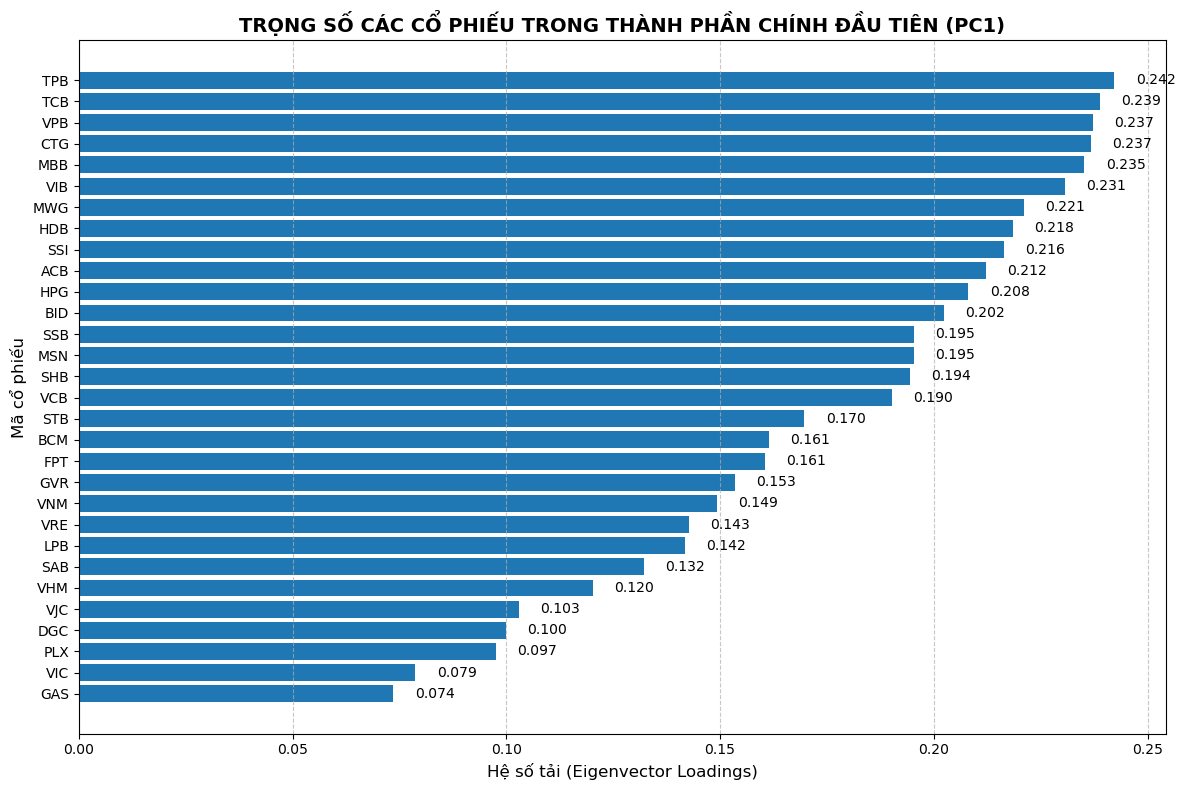

--------------------------------------------------
BẢNG TRỌNG SỐ CÁC CỔ PHIẾU (SẮP XẾP TỪ CAO ĐẾN THẤP):


,Ticker,Weight (Loading)
0,TPB,0.242231
1,TCB,0.238825
2,VPB,0.237200
3,CTG,0.236689
4,MBB,0.235242
5,VIB,0.230728
6,MWG,0.221030
7,HDB,0.218465
8,SSI,0.216307
9,ACB,0.212131


In [13]:
# 1. Tạo DataFrame kết hợp tên mã cổ phiếu và trọng số tương ứng từ vector riêng PC1
df_weights = pd.DataFrame({
    'Ticker': stocks_returns.columns,
    'Weight (Loading)': pc1_eigenvector
})

# 2. Sắp xếp các mã cổ phiếu theo độ lớn của trọng số (từ cao xuống thấp)
# Sử dụng giá trị tuyệt đối nếu chỉ quan tâm đến cường độ tác động,
# nhưng ở đây ta giữ nguyên dấu để quan sát tính đồng biến/nghịch biến.
df_weights = df_weights.sort_values(by='Weight (Loading)', ascending=False).reset_index(drop=True)

# 3. Trực quan hóa trọng số bằng biểu đồ thanh ngang (Bar Chart)
plt.figure(figsize=(12, 8))

# Đổi màu: xanh cho trọng số dương (cùng chiều PC1), đỏ cho trọng số âm (ngược chiều PC1)
colors = ['#1f77b4' if x > 0 else '#d62728' for x in df_weights['Weight (Loading)']]

bars = plt.barh(df_weights['Ticker'], df_weights['Weight (Loading)'], color=colors)

plt.title('TRỌNG SỐ CÁC CỔ PHIẾU TRONG THÀNH PHẦN CHÍNH ĐẦU TIÊN (PC1)', fontsize=14, fontweight='bold')
plt.xlabel('Hệ số tải (Eigenvector Loadings)', fontsize=12)
plt.ylabel('Mã cổ phiếu', fontsize=12)
plt.gca().invert_yaxis() # Đảo trục Y để mã có trọng số lớn nhất nằm trên cùng
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Gắn nhãn giá trị lên từng thanh
for bar in bars:
    width = bar.get_width()
    label_x_pos = width + 0.005 if width > 0 else width - 0.025
    plt.text(label_x_pos, bar.get_y() + bar.get_height()/2, f'{width:.3f}',
             va='center', fontsize=10)

plt.tight_layout()
plt.show()

# 4. Hiển thị bảng dữ liệu để đưa vào báo cáo
print("-" * 50)
print("BẢNG TRỌNG SỐ CÁC CỔ PHIẾU (SẮP XẾP TỪ CAO ĐẾN THẤP):")
display(df_weights)

# PC2

C:\Users\hello\AppData\Local\Temp\ipykernel_5604\1785651037.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=df_loadings_pc2, x='Ticker', y='PC2_Loading', palette='coolwarm')


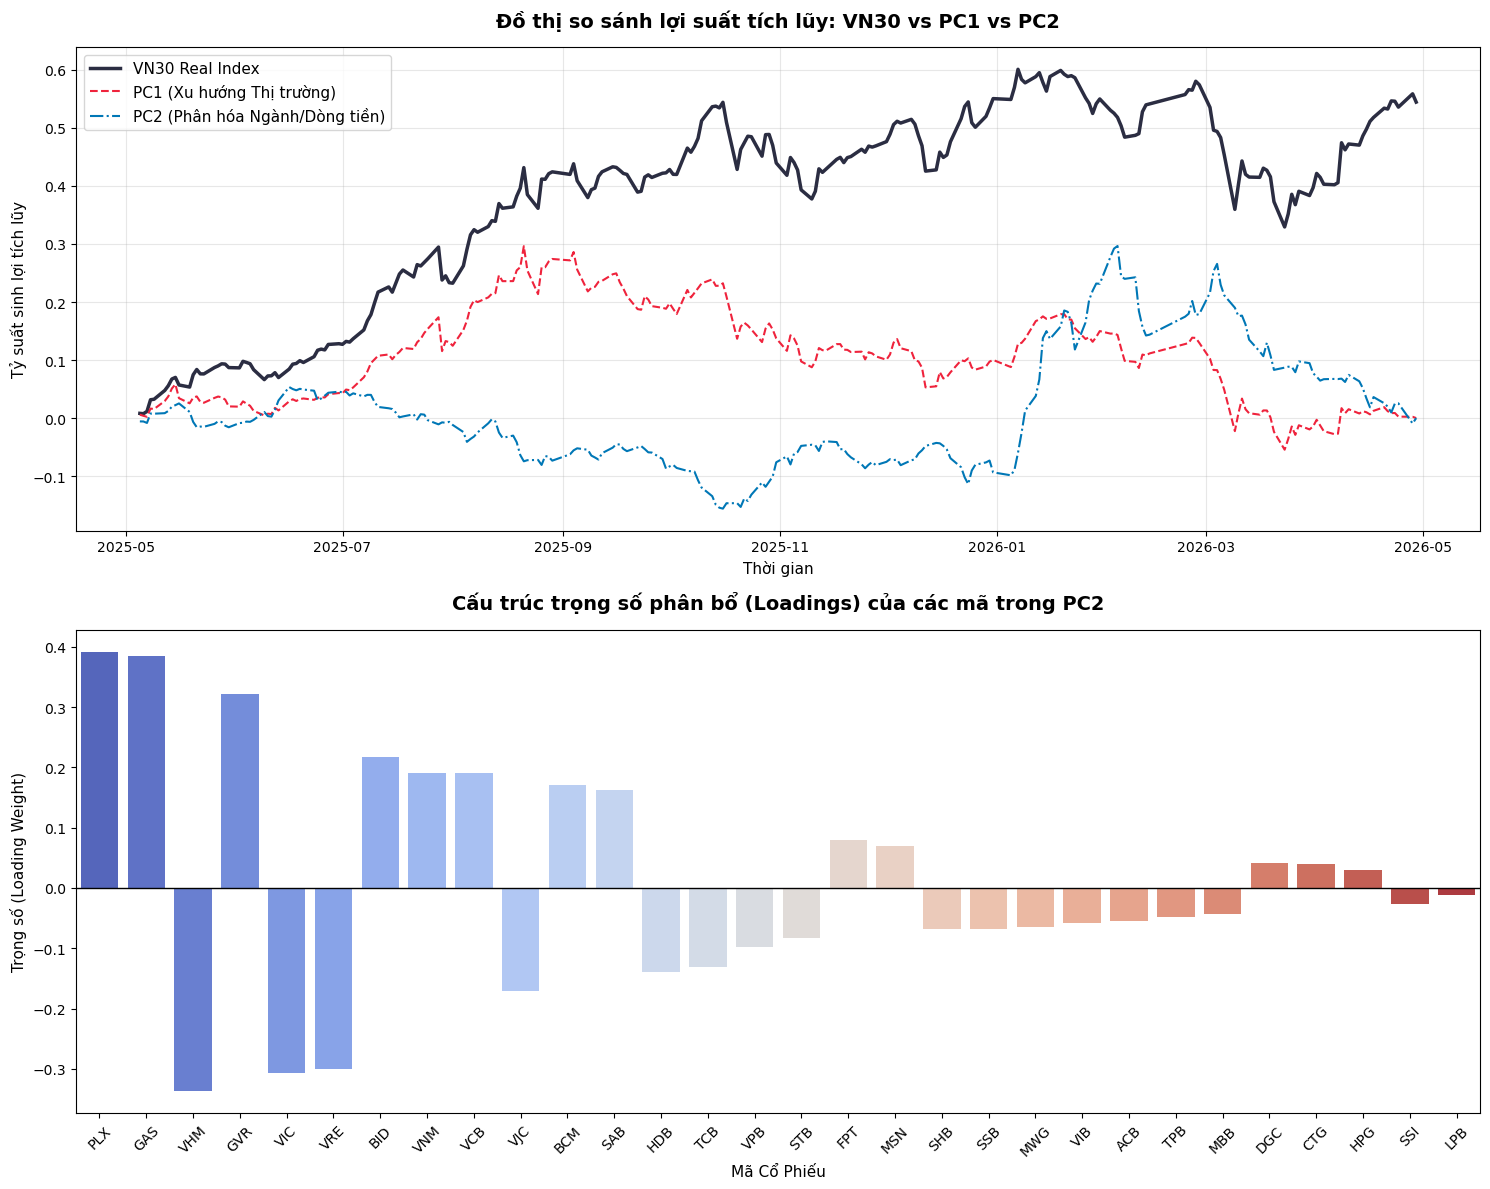

--- KẾT QUẢ KIỂM ĐỊNH TƯƠNG QUAN ---
Hệ số tương quan (PC1 vs VN30): 0.9192
Hệ số tương quan (PC2 vs VN30): -0.2491 (Gần bằng 0 do tính trực giao của thuật toán PCA)


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. TÍNH TOÁN CHUỖI THỜI GIAN VÀ KHỬ LỖI DẤU (SIGN AMBIGUITY) CHO PC1 & PC2
# =====================================================================

# Lấy eigenvector cho PC1 (cột 0) và PC2 (cột 1)
pc1_eigenvector = eigenvectors[:, 0]
pc2_eigenvector = eigenvectors[:, 1]

# Tính chuỗi lợi suất (Returns) từ dữ liệu đã chuẩn hóa X_scaled
pc1_returns = np.dot(X_scaled, pc1_eigenvector)
pc2_returns = np.dot(X_scaled, pc2_eigenvector)

# Xác định chuỗi VN30 thực tế để làm mốc đối chiếu
if 'VN30' in df_returns.columns:
    vn30_returns = df_returns['VN30'].values
else:
    vn30_returns = df_returns.mean(axis=1).values  # Dự phòng nếu không có cột VN30 riêng

# Khử hiện tượng Sign Ambiguity (Đảo dấu nếu tương quan bị âm ngược với thị trường)
if np.corrcoef(pc1_returns, vn30_returns)[0, 1] < 0:
    pc1_returns = -pc1_returns
    pc1_eigenvector = -pc1_eigenvector

# Điều chỉnh biên độ dao động (Volatility Rescaling) về cùng mức với VN30
vn30_std = vn30_returns.std()
pc1_returns_adjusted = pc1_returns * (vn30_std / pc1_returns.std())
pc2_returns_adjusted = pc2_returns * (vn30_std / pc2_returns.std())

# Tính toán lợi suất lũy kế (Cumulative Returns)
df_cum_notebook = pd.DataFrame(index=df_returns.index)
df_cum_notebook['VN30 Real Index'] = np.exp(vn30_returns.cumsum()) - 1
df_cum_notebook['PC1 (Market Trend)'] = np.exp(pc1_returns_adjusted.cumsum()) - 1
df_cum_notebook['PC2 (Sector Differentiation)'] = np.exp(pc2_returns_adjusted.cumsum()) - 1


# =====================================================================
# 2. TRỰC QUAN HÓA ĐỒ THỊ 
# =====================================================================

# Khởi tạo khung vẽ chứa cả 2 biểu đồ liền kề nhau để dễ quan sát
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# --- Đồ thị 1: Chuỗi thời gian lũy kế VN30 vs PC1 vs PC2 ---
axes[0].plot(df_cum_notebook.index, df_cum_notebook['VN30 Real Index'], label='VN30 Real Index', color='#2B2D42', linewidth=2.5)
axes[0].plot(df_cum_notebook.index, df_cum_notebook['PC1 (Market Trend)'], label='PC1 (Xu hướng Thị trường)', color='#EF233C', linestyle='--')
axes[0].plot(df_cum_notebook.index, df_cum_notebook['PC2 (Sector Differentiation)'], label='PC2 (Phân hóa Ngành/Dòng tiền)', color='#0077B6', linestyle='-.')

axes[0].set_title('Đồ thị so sánh lợi suất tích lũy: VN30 vs PC1 vs PC2', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Thời gian', fontsize=11)
axes[0].set_ylabel('Tỷ suất sinh lợi tích lũy', fontsize=11)
axes[0].legend(fontsize=11, loc='upper left')
axes[0].grid(True, alpha=0.3)


# --- Đồ thị 2: Trọng số cấu trúc (Loadings) của PC2 ---
df_loadings_pc2 = pd.DataFrame({
    'Ticker': features,
    'PC2_Loading': pc2_eigenvector
}).sort_values(by='PC2_Loading', key=abs, ascending=False)

# Dùng bảng màu coolwarm (Xanh - Trắng - Đỏ) để làm nổi bật sự đối lập âm/dương của các nhóm ngành
sns.barplot(ax=axes[1], data=df_loadings_pc2, x='Ticker', y='PC2_Loading', palette='coolwarm')
axes[1].axhline(0, color='black', linewidth=1, linestyle='-')

axes[1].set_title('Cấu trúc trọng số phân bổ (Loadings) của các mã trong PC2', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Mã Cổ Phiếu', fontsize=11)
axes[1].set_ylabel('Trọng số (Loading Weight)', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)

# Tối ưu không gian hiển thị, tránh chồng chéo chữ
plt.tight_layout()
plt.show()

# In thêm thông số kiểm tra nhanh
corr_pc1 = np.corrcoef(pc1_returns, vn30_returns)[0, 1]
corr_pc2 = np.corrcoef(pc2_returns, vn30_returns)[0, 1]
print(f"--- KẾT QUẢ KIỂM ĐỊNH TƯƠNG QUAN ---")
print(f"Hệ số tương quan (PC1 vs VN30): {corr_pc1:.4f}")
print(f"Hệ số tương quan (PC2 vs VN30): {corr_pc2:.4f} (Gần bằng 0 do tính trực giao của thuật toán PCA)")

# 1. Đồ thị 1: Xu hướng Lợi suất tích lũy (VN30 vs PC1 vs PC2)
- PC1 - Nhân tố Xu hướng Thị trường (Market Factor): 
    * Hệ số tương quan giữa PC1 và VN30 đạt tới 0.9192 (cực kỳ cao). Điều này chứng minh PC1 phản ánh chính xác hơi thở chung của toàn bộ thị trường. Khi VN30 tăng, PC1 tăng và ngược lại.
- PC2 - Nhân tố Phân hóa và Luân chuyển dòng tiền (Sector/Style Factor):
    * Đường nét đứt màu xanh (PC2) chuyển động hoàn toàn độc lập với VN30. Giai đoạn từ tháng 05/2025 đến 11/2025, trong khi thị trường chung tăng trưởng thì PC2 lại liên tục sụt giảm sâu xuống mức -0.1.
    * Tuy nhiên, bước sang giai đoạn từ tháng 12/2025 đến 02/2026, PC2 có cú lội ngược dòng dựng đứng lên mức gần $+0.3$. Đây chính là dấu vết của hiện tượng luân chuyển dòng tiền quy mô lớn giữa các nhóm ngành đối trọng trong rổ VN30.
# 2. Đồ thị 2: Cấu trúc Trọng số (PC2 Loadings)
Để hiểu tại sao PC2 lại biến động như trên, hãy nhìn vào sự phân hóa đối lập rất rõ ràng của các thanh loading:
- Nhóm Trọng số Dương lớn (Phía trên trục 0)
    * Mã tiêu biểu: PLX, GAS, GVR, BID, VNM, VCB, BCM, SAB.
    * Đặc trưng ngành: Chiếm ưu thế bởi nhóm Năng lượng/Hóa chất/Hàng tiêu dùng lớn (PLX, GAS, GVR, VNM, SAB) kết hợp với một vài cổ phiếu Ngân hàng quốc doanh đầu ngành (BID, VCB).
- Nhóm Trọng số Âm lớn (Đâm sâu xuống dưới trục 0)
    * Mã tiêu biểu: VHM, VIC, VRE, VJC, HDB, TCB.
    * Đặc trưng ngành: Chiếm trọn bộ là Họ nhà Vin / Bất động sản (VHM, VIC, VRE) cùng với nhóm Ngân hàng thương mại cổ phần tư nhân (TCB, HDB).
# 3. Kết luận 
💡 Ý nghĩa cốt lõi của PC2: > Thành phần chính số 2 (PC2) đóng vai trò là một "Cán cân đối trọng ngành". Nó bộc lộ sự dịch chuyển dòng tiền mang tính cấu trúc của thị trường chứng khoán Việt Nam giai đoạn 2025–2026.
- Khi dòng tiền rút mạnh khỏi nhóm Bất động sản (họ Vin) và Ngân hàng tư nhân (TCB, HDB), đồng thời dịch chuyển sang trú ẩn ở nhóm Năng lượng, Tiêu dùng và Bank quốc doanh -> PC2 sẽ lao dốc mạnh (giai đoạn giữa năm 2025).
- Ngược lại, khi nhóm Bất động sản thương mại và các cổ phiếu tài chính tư nhân hồi phục bứt phá -> PC2 sẽ tăng trưởng dựng đứng (giai đoạn đầu năm 2026).